In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nelgiriyewithana/global-missing-migrants-dataset/Global Missing Migrants Dataset.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nelgiriyewithana/global-missing-migrants-dataset/Global Missing Migrants Dataset.csv')

df.head()

,Incident Type,Incident year,Reported Month,Region of Origin,Region of Incident,Country of Origin,Number of Dead,Minimum Estimated Number of Missing,Total Number of Dead and Missing,Number of Survivors,Number of Females,Number of Males,Number of Children,Cause of Death,Migration route,Location of death,Information Source,Coordinates,UNSD Geographical Grouping
0,Incident,2014,January,Central America,North America,Guatemala,1.0,0,1,0,0,1,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,"31.650259, -110.366453",Northern America
1,Incident,2014,January,Latin America / Caribbean (P),North America,Unknown,1.0,0,1,0,0,0,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,"31.59713, -111.73756",Northern America
2,Incident,2014,January,Latin America / Caribbean (P),North America,Unknown,1.0,0,1,0,0,0,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,"31.94026, -113.01125",Northern America
3,Incident,2014,January,Central America,North America,Mexico,1.0,0,1,0,0,1,0,Violence,US-Mexico border crossing,"near Douglas, Arizona, USA","Ministry of Foreign Affairs Mexico, Pima Count...","31.506777, -109.315632",Northern America
4,Incident,2014,January,Northern Africa,Europe,Sudan,1.0,0,1,2,0,1,0,Harsh environmental conditions / lack of adequ...,NaN,Border between Russia and Estonia,EUBusiness (Agence France-Presse),"59.1551, 28",Northern Europe


In [4]:
#veriication that data is loaded correctly
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (13020, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13020 entries, 0 to 13019
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Incident Type                        13020 non-null  object 
 1   Incident year                        13020 non-null  int64  
 2   Reported Month                       13020 non-null  object 
 3   Region of Origin                     12998 non-null  object 
 4   Region of Incident                   13020 non-null  object 
 5   Country of Origin                    13012 non-null  object 
 6   Number of Dead                       12470 non-null  float64
 7   Minimum Estimated Number of Missing  13020 non-null  int64  
 8   Total Number of Dead and Missing     13020 non-null  int64  
 9   Number of Survivors                  13020 non-null  int64  
 10  Number of Females                    13020 non-null  int64  
 11

In [5]:
#Checking Missing values
df.isnull().sum()

Incident Type                             0
Incident year                             0
Reported Month                            0
Region of Origin                         22
Region of Incident                        0
Country of Origin                         8
Number of Dead                          550
Minimum Estimated Number of Missing       0
Total Number of Dead and Missing          0
Number of Survivors                       0
Number of Females                         0
Number of Males                           0
Number of Children                        0
Cause of Death                            0
Migration route                        3021
Location of death                         0
Information Source                        8
Coordinates                              36
UNSD Geographical Grouping                1
dtype: int64

**Handing of Missing Values**


* A categorical feature i.e Migration Routes is missing so we will fill missing values with "Unknown".
* Missing Number of Deaths will be replaced by median to reduces the influence of extreme values in death counts.
* Since Coordinates column will later be split into Latitude and Longitude, fill with a placeholder first (0,0)
* Region of origin, Country of Origin and Information source all missing values will be filled with "Unknown"


In [6]:
df['Migration route'] = df['Migration route'].fillna("Unknown")
df['Number of Dead'] = df['Number of Dead'].fillna(df['Number of Dead'].median())
df['Coordinates'] = df['Coordinates'].fillna("0,0")
df['Region of Origin'] = df['Region of Origin'].fillna("Unknown")
df['Country of Origin'] = df['Country of Origin'].fillna("Unknown")
df['Information Source'] = df['Information Source'].fillna("Unknown")
df['UNSD Geographical Grouping'] = df['UNSD Geographical Grouping'].fillna("Unknown")

In [7]:
#Verification that missing values are dealt with
df.isnull().sum()

Incident Type                          0
Incident year                          0
Reported Month                         0
Region of Origin                       0
Region of Incident                     0
Country of Origin                      0
Number of Dead                         0
Minimum Estimated Number of Missing    0
Total Number of Dead and Missing       0
Number of Survivors                    0
Number of Females                      0
Number of Males                        0
Number of Children                     0
Cause of Death                         0
Migration route                        0
Location of death                      0
Information Source                     0
Coordinates                            0
UNSD Geographical Grouping             0
dtype: int64

**Coordinate Pre Processiong**
Splitting coordinates into latitude and longitude and then drop the original column

In [8]:
df[['Latitude','Longitude']] = df['Coordinates'].str.split(',', expand=True)

df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# Verification checks
print("Columns after split:", df[['Latitude','Longitude']].columns)

print("\nMissing values after conversion:")
print(df[['Latitude','Longitude']].isna().sum())

# Check valid coordinate ranges
invalid_lat = df[(df['Latitude'] < -90) | (df['Latitude'] > 90)]
invalid_lon = df[(df['Longitude'] < -180) | (df['Longitude'] > 180)]

print("\nInvalid Latitude rows:", len(invalid_lat))
print("Invalid Longitude rows:", len(invalid_lon))

# Show sample rows
print("\nSample of split coordinates:")
print(df[['Latitude','Longitude']].head())

df.drop(columns=['Coordinates'], inplace=True)

Columns after split: Index(['Latitude', 'Longitude'], dtype='object')

Missing values after conversion:
Latitude     0
Longitude    0
dtype: int64

Invalid Latitude rows: 0
Invalid Longitude rows: 0

Sample of split coordinates:
    Latitude   Longitude
0  31.650259 -110.366453
1  31.597130 -111.737560
2  31.940260 -113.011250
3  31.506777 -109.315632
4  59.155100   28.000000


# Histogram – Number of Dead and Missing

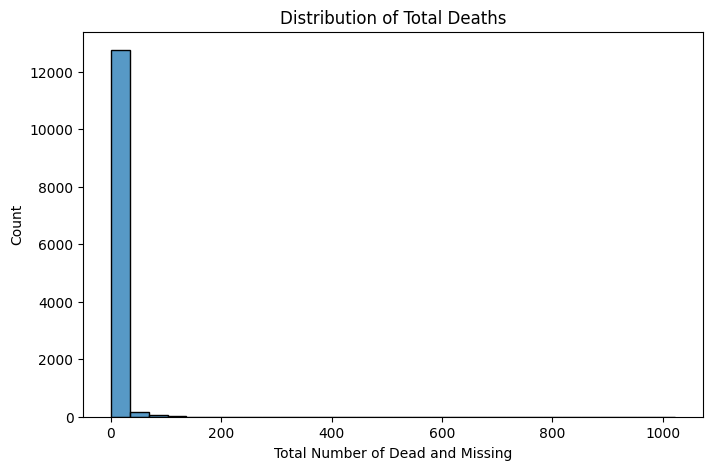

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Number of Dead and Missing'], bins=30)
plt.title("Distribution of Total Deaths")
plt.show()

Most incidents involve small numbers of migrants, while a few incidents have very high death counts.

# Migration Route Distribution

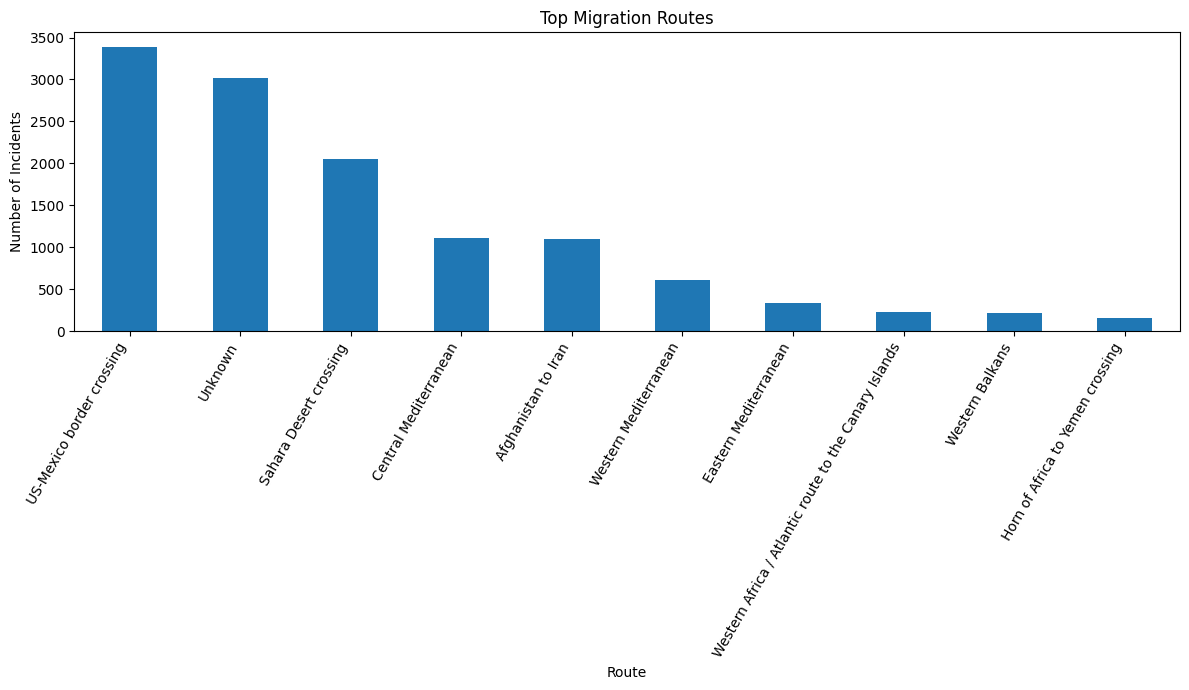

In [10]:
plt.figure(figsize=(12,7))  # wider
df['Migration route'].value_counts().head(10).plot(kind='bar')
plt.title("Top Migration Routes")
plt.xlabel("Route")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=60, ha='right')  # rotate more, align right
plt.tight_layout()  # automatically adjust spacing
plt.show()

Some migration routes appear significantly more frequently, indicating high-risk migration corridors.

# Cause of Death Distribution

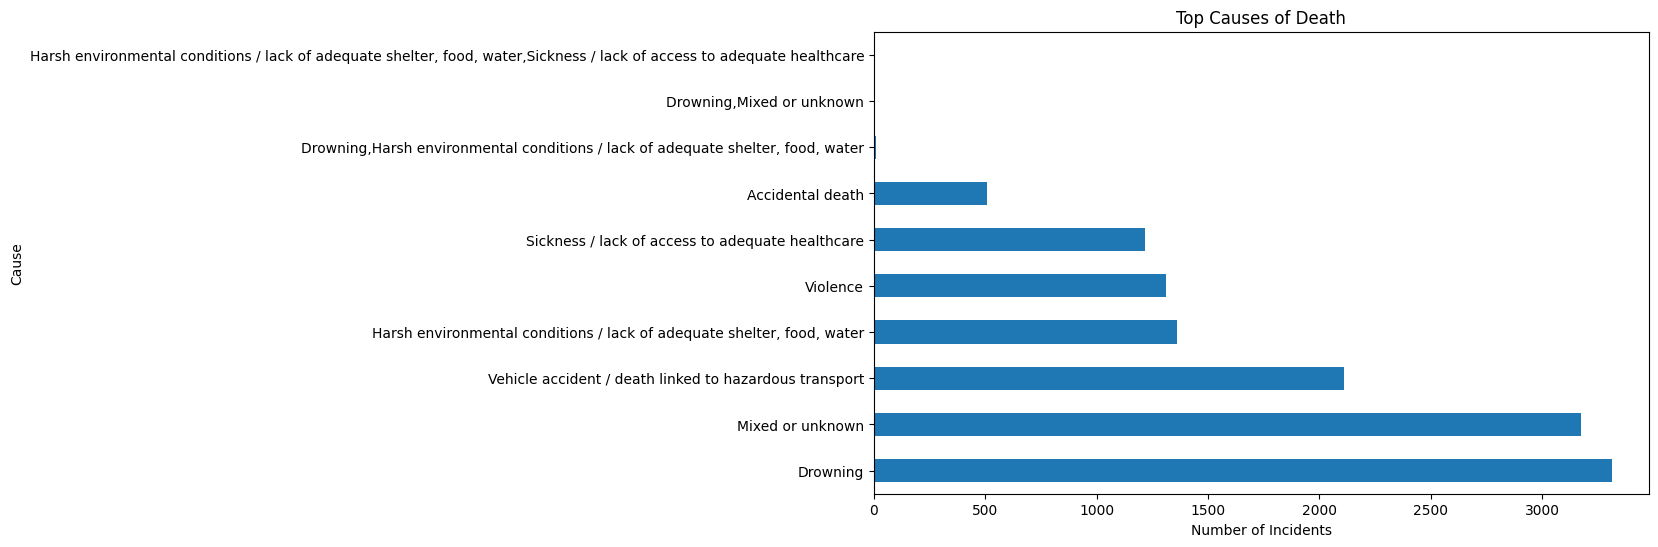

In [11]:
df['Cause of Death'].value_counts().head(10).plot(kind='barh', figsize=(10,6))
plt.title("Top Causes of Death")
plt.xlabel("Number of Incidents")
plt.ylabel("Cause")
plt.show()

# Correlation Heatmap

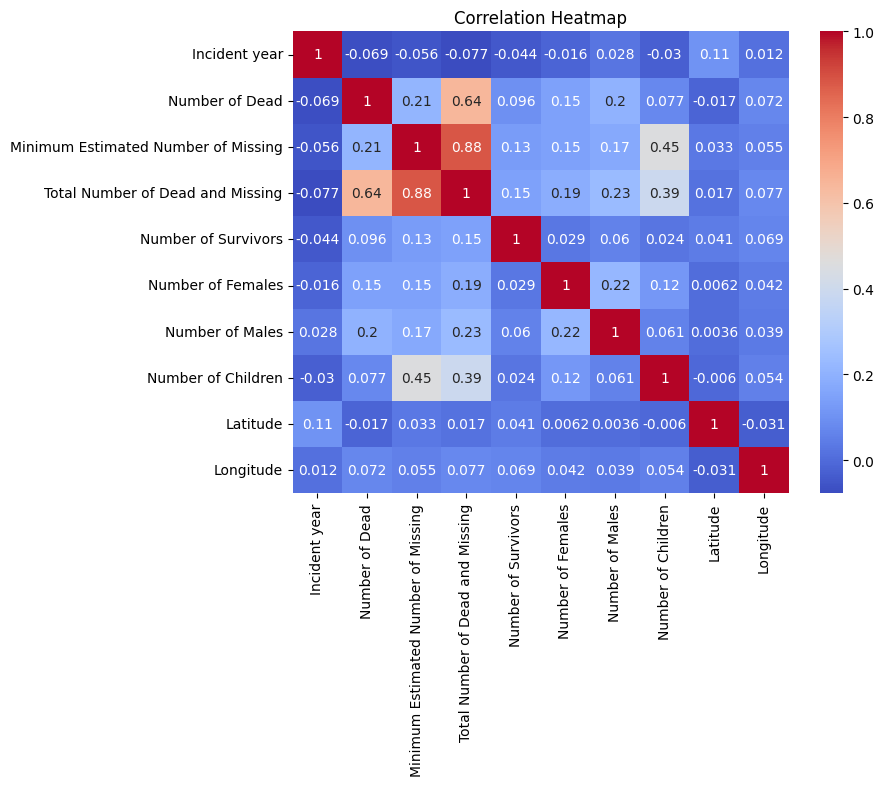

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Map Visualization

In [13]:
import plotly.express as px

fig = px.scatter_geo(df,
                     lat='Latitude',
                     lon='Longitude',
                     opacity=0.3,
                     title="Global Missing Migrants Incident Locations")
fig.show()

# Encode Categorical Variables

Applying Machine learning algorithms cannot process text categories directly, so they must be converted into numerical format.

In [14]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    'Incident Type',
    'Reported Month',
    'Region of Origin',
    'Region of Incident',
    'Cause of Death',
    'Migration route',
    'UNSD Geographical Grouping'
]

# Correct parameter for recent sklearn versions
ohe = OneHotEncoder(sparse_output=False)

encoded_array = ohe.fit_transform(df[categorical_cols])

print(ohe.get_feature_names_out(categorical_cols))

['Incident Type_Cumulative Incident' 'Incident Type_Incident'
 'Incident Type_Incident,Split Incident' 'Incident Type_Split Incident'
 'Reported Month_April' 'Reported Month_August' 'Reported Month_December'
 'Reported Month_February' 'Reported Month_January' 'Reported Month_July'
 'Reported Month_June' 'Reported Month_March' 'Reported Month_May'
 'Reported Month_November' 'Reported Month_October'
 'Reported Month_September' 'Region of Origin_Caribbean'
 'Region of Origin_Caribbean (P)' 'Region of Origin_Central America'
 'Region of Origin_Central America (P)' 'Region of Origin_Central Asia'
 'Region of Origin_Eastern Africa' 'Region of Origin_Eastern Africa (P)'
 'Region of Origin_Eastern Asia' 'Region of Origin_Eastern Asia (P)'
 'Region of Origin_Europe'
 'Region of Origin_Latin America / Caribbean (P)'
 'Region of Origin_Middle Africa' 'Region of Origin_Mixed'
 'Region of Origin_Northern Africa' 'Region of Origin_Northern Africa (P)'
 'Region of Origin_Northern America' 'Region of 

# Saving the File

In [15]:
df.to_csv("missing_migrants_preprocessed.csv", index=False)